In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('marketing_campaign_data.csv')

# Data Overview

In [32]:
df.sample(5)

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1940,1940,1139,1984,S3,Menikah,73356000.0,0,0,06-02-2014,56,1050000,14000,322000,0,14000,112000,1,5,11,5,2,1,0,1,1,0,0,3,11,1
1462,1462,2945,1955,S3,Bertunangan,46015000.0,1,1,13-04-2014,25,38000,0,2000,0,0,6000,1,1,0,3,7,1,0,0,0,1,0,3,11,0
2018,2018,255,1951,S1,Cerai,22263000.0,1,1,30-03-2014,31,17000,0,2000,0,0,2000,2,1,0,3,6,0,0,0,0,0,1,3,11,0
760,760,10270,1981,D3,Menikah,35523000.0,1,0,03-10-2013,8,11000,5000,22000,12000,5000,11000,2,3,0,3,7,0,0,0,0,0,0,3,11,0
1927,1927,2181,1970,S1,Menikah,70617000.0,0,0,23-06-2013,45,353000,61000,753000,40000,46000,27000,1,3,3,7,2,0,0,0,0,0,0,3,11,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2240 non-null   int64  
 1   ID                   2240 non-null   int64  
 2   Year_Birth           2240 non-null   int64  
 3   Education            2240 non-null   object 
 4   Marital_Status       2240 non-null   object 
 5   Income               2216 non-null   float64
 6   Kidhome              2240 non-null   int64  
 7   Teenhome             2240 non-null   int64  
 8   Dt_Customer          2240 non-null   object 
 9   Recency              2240 non-null   int64  
 10  MntCoke              2240 non-null   int64  
 11  MntFruits            2240 non-null   int64  
 12  MntMeatProducts      2240 non-null   int64  
 13  MntFishProducts      2240 non-null   int64  
 14  MntSweetProducts     2240 non-null   int64  
 15  MntGoldProds         2240 non-null   i

# Data Preperation

In [34]:
# Missing Values
df.isna().sum()

Unnamed: 0              0
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntCoke                 0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [35]:
df.dropna(inplace=True)

In [36]:
# Nilai Duplikat
df.duplicated().sum()

np.int64(0)

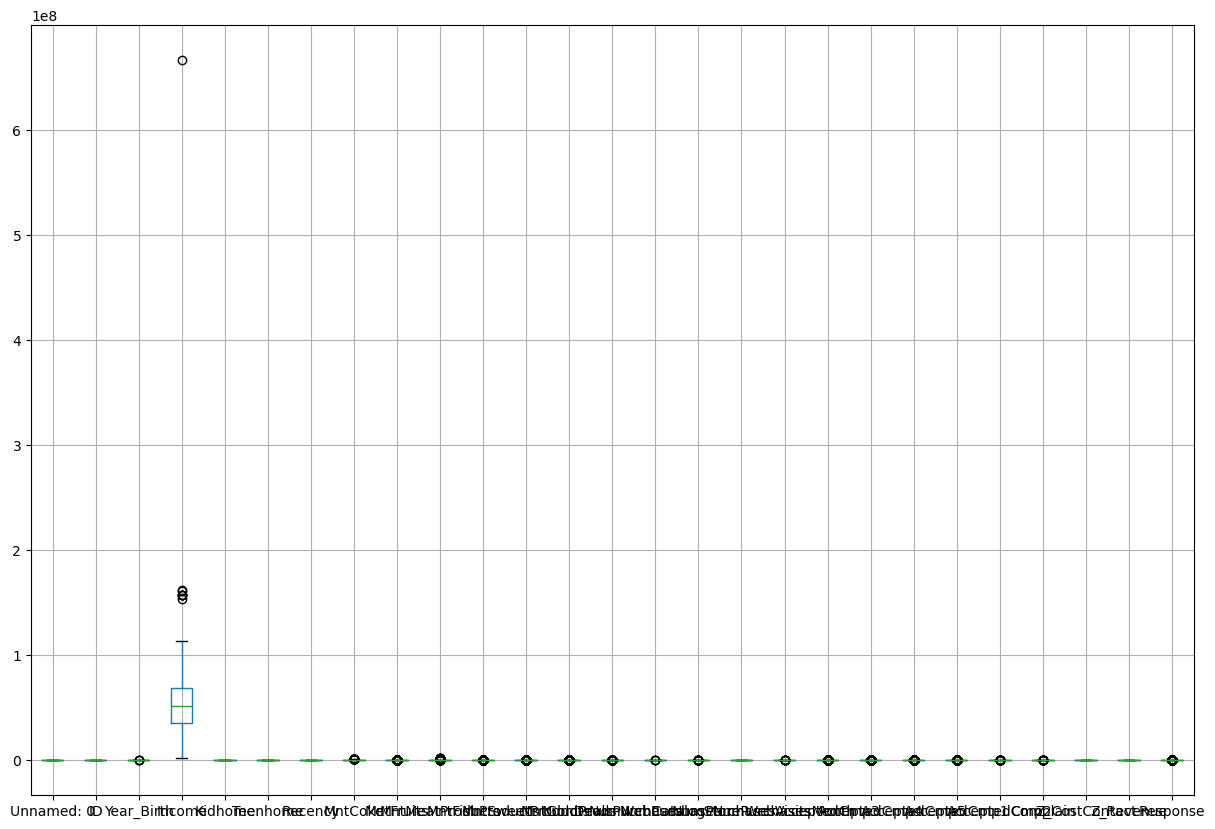

In [37]:
# Outliers
fig, ax = plt.subplots(figsize=(15, 10))

df.boxplot(ax=ax)
plt.show()

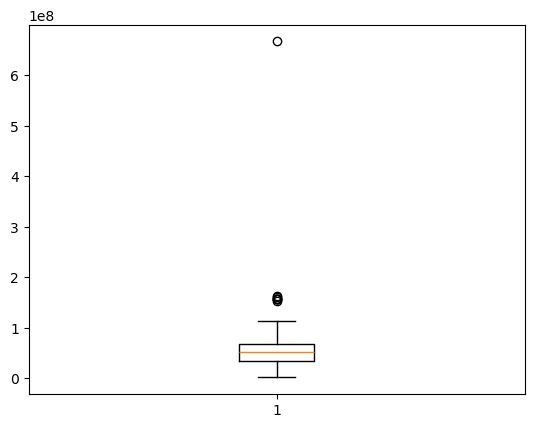

In [38]:
plt.boxplot(df['Income'])
plt.show()

In [39]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Income'] < (Q1 - 1.5 * IQR)) | (df['Income'] > (Q3 + 1.5 * IQR))]

print("Banyaknya Nilai Outliers:", len(outliers))

Banyaknya Nilai Outliers: 8


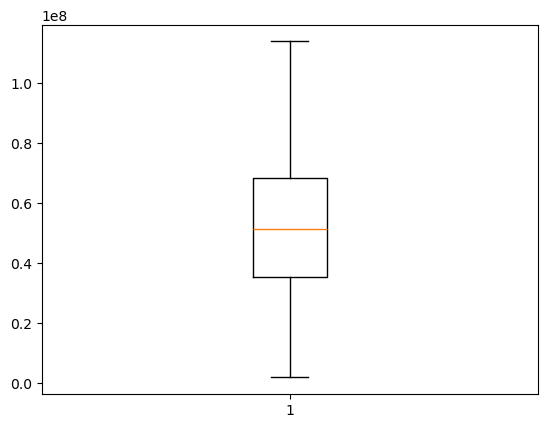

In [40]:
# Menghapus nilai outliers
df = df[~((df['Income'] < (Q1 - 1.5 * IQR)) | (df['Income'] > (Q3 + 1.5 * IQR)))]
plt.boxplot(df['Income'])
plt.show()

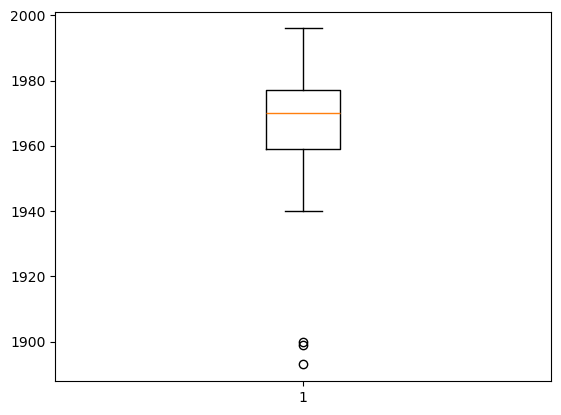

In [41]:
plt.boxplot(df['Year_Birth'])
plt.show()

In [42]:
Q1 = df['Year_Birth'].quantile(.25)
Q3 = df['Year_Birth'].quantile(.75)
IQR = Q3-Q1

outliers = df[(df['Year_Birth']<(Q1 - 1.5 * IQR)) | (df['Year_Birth']>(Q3+1.5*IQR))]
print('Nilai outliers pada Tahun Lahir: ',len(outliers))

Nilai outliers pada Tahun Lahir:  3


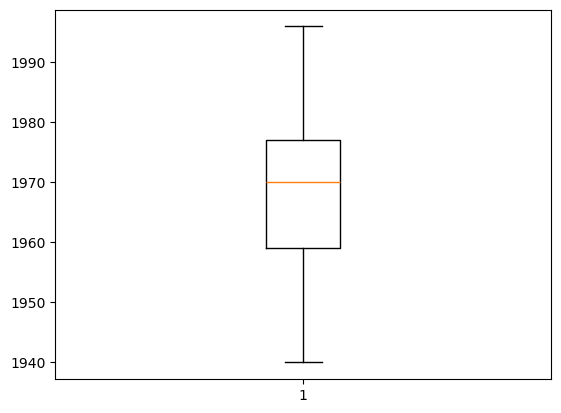

In [43]:
df = df[~((df['Year_Birth']<(Q1 - 1.5 * IQR)) | (df['Year_Birth']>(Q3+1.5*IQR)))]
plt.boxplot(df['Year_Birth'])
plt.show()

# Feature Engineering

In [44]:
#Mengubah tipedata dari kolom Dt_customer menjadi tanggal
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')
df['tanggal_dummy'] = df['Dt_Customer']+pd.to_timedelta(df['Recency'],unit='D')
df.sort_values(['tanggal_dummy'],ascending=False)

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,tanggal_dummy
1800,1800,2831,1976,S1,Bertunangan,78416000.0,0,1,2014-06-27,99,453000,38000,279000,188000,38000,183000,2,7,7,10,3,0,0,0,0,0,0,3,11,0,2014-10-04
796,796,6722,1954,S3,Menikah,70421000.0,0,1,2014-06-28,98,479000,28000,136000,75000,14000,35000,3,10,3,7,6,0,0,0,0,0,0,3,11,0,2014-10-04
2054,2054,6382,1953,S1,Bertunangan,48794000.0,1,1,2014-06-26,97,25000,0,11000,3000,0,15000,1,1,0,3,4,0,0,0,0,0,0,3,11,0,2014-10-01
178,178,10492,1959,S1,Bertunangan,38285000.0,2,1,2014-06-24,96,2000,0,5000,2000,0,1000,1,0,0,3,2,0,0,0,0,0,0,3,11,0,2014-09-28
1486,1486,2939,1970,S2,Bertunangan,79419000.0,0,0,2014-06-22,96,751000,127000,687000,20000,15000,31000,1,4,6,4,2,0,0,0,0,0,0,3,11,0,2014-09-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2139,2139,2715,1966,S2,Cerai,29435000.0,1,1,2012-08-06,11,70000,3000,37000,4000,2000,64000,4,3,2,2,9,0,0,0,0,0,0,3,11,1,2012-08-17
1953,1953,7919,1976,S3,Bertunangan,72335000.0,0,0,2012-08-13,2,1285000,105000,653000,28000,21000,0,1,10,4,8,8,0,0,0,0,0,0,3,11,1,2012-08-15
51,51,4114,1964,S2,Menikah,79143000.0,0,0,2012-08-11,2,650000,37000,780000,27000,167000,32000,1,6,9,13,3,0,0,0,0,0,0,3,11,0,2012-08-13
654,654,3277,1955,S1,Cerai,49431000.0,0,1,2012-08-03,9,219000,3000,100000,26000,0,17000,2,7,1,5,8,0,0,0,0,0,0,3,11,0,2012-08-12


In [45]:
# Feature Extraction
df['Usia'] = 2014 - df['Year_Birth']
df.head()

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,tanggal_dummy,Usia
0,0,5524,1957,S1,Lajang,58138000.0,0,0,2012-09-04,58,635000,88000,546000,172000,88000,88000,3,8,10,4,7,0,0,0,0,0,0,3,11,1,2012-11-01,57
1,1,2174,1954,S1,Lajang,46344000.0,1,1,2014-03-08,38,11000,1000,6000,2000,1000,6000,2,1,1,2,5,0,0,0,0,0,0,3,11,0,2014-04-15,60
2,2,4141,1965,S1,Bertunangan,71613000.0,0,0,2013-08-21,26,426000,49000,127000,111000,21000,42000,1,8,2,10,4,0,0,0,0,0,0,3,11,0,2013-09-16,49
3,3,6182,1984,S1,Bertunangan,26646000.0,1,0,2014-02-10,26,11000,4000,20000,10000,3000,5000,2,2,0,4,6,0,0,0,0,0,0,3,11,0,2014-03-08,30
4,4,5324,1981,S3,Menikah,58293000.0,1,0,2014-01-19,94,173000,43000,118000,46000,27000,15000,5,5,3,6,5,0,0,0,0,0,0,3,11,0,2014-04-23,33


In [46]:
df['Is_Couple'] = np.where(((df['Marital_Status']=='Menikah') | (df['Marital_Status']=='Bertunangan')),1,0)
df['Is_SMA']=np.where(df['Education']=='SMA',1,0)

In [47]:
df['Anak']=(df[['Kidhome','Teenhome']]).sum(axis=1)
df['cmp_masuk'] = (df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']]).sum(axis=1)

In [48]:
df['Spent'] = df['MntCoke']+df['MntFruits']+ df['MntMeatProducts'] +df['MntFishProducts']+df['MntSweetProducts']+ df['MntGoldProds']
df['deals_rate'] = df['NumDealsPurchases']/(df['NumWebPurchases']+df['NumCatalogPurchases']+df['NumStorePurchases']+df['NumDealsPurchases'])
df['conversion_rate'] = df['NumWebPurchases']/(df['NumWebVisitsMonth']+df['NumWebPurchases'])

In [49]:
def rentangusia(Usia):
    if Usia<=30:
        return 'Muda'
    elif Usia<=55:
        return 'Tua'
    else:
        return 'Lansia'

df['rentang'] = df['Usia'].apply(rentangusia)

In [50]:
df.head()

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,tanggal_dummy,Usia,Is_Couple,Is_SMA,Anak,cmp_masuk,Spent,deals_rate,conversion_rate,rentang
0,0,5524,1957,S1,Lajang,58138000.0,0,0,2012-09-04,58,635000,88000,546000,172000,88000,88000,3,8,10,4,7,0,0,0,0,0,0,3,11,1,2012-11-01,57,0,0,0,0,1617000,0.120000,0.533333,Lansia
1,1,2174,1954,S1,Lajang,46344000.0,1,1,2014-03-08,38,11000,1000,6000,2000,1000,6000,2,1,1,2,5,0,0,0,0,0,0,3,11,0,2014-04-15,60,0,0,2,0,27000,0.333333,0.166667,Lansia
2,2,4141,1965,S1,Bertunangan,71613000.0,0,0,2013-08-21,26,426000,49000,127000,111000,21000,42000,1,8,2,10,4,0,0,0,0,0,0,3,11,0,2013-09-16,49,1,0,0,0,776000,0.047619,0.666667,Tua
3,3,6182,1984,S1,Bertunangan,26646000.0,1,0,2014-02-10,26,11000,4000,20000,10000,3000,5000,2,2,0,4,6,0,0,0,0,0,0,3,11,0,2014-03-08,30,1,0,1,0,53000,0.250000,0.250000,Muda
4,4,5324,1981,S3,Menikah,58293000.0,1,0,2014-01-19,94,173000,43000,118000,46000,27000,15000,5,5,3,6,5,0,0,0,0,0,0,3,11,0,2014-04-23,33,1,0,1,0,422000,0.263158,0.500000,Tua


In [58]:
# # Feature Selection
# new_df = df.drop(columns=['ID'])
new_df = df.copy()

# Exploratory Data Analytics(EDA)

In [59]:
# Decriptive Analysis
numericals = new_df.select_dtypes(include='number').columns
new_df[numericals].describe()

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntCoke,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Usia,Is_Couple,Is_SMA,Anak,cmp_masuk,Spent,deals_rate,conversion_rate
count,2205.000000,2205.000000,2205.000000,2.205000e+03,2205.000000,2205.000000,2205.000000,2.205000e+03,2205.000000,2.205000e+03,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.0,2205.0,2205.00000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000,2.205000e+03,2203.000000,2205.000000
mean,1122.833107,5585.439456,1968.904308,5.162209e+07,0.442177,0.506576,49.009070,3.061646e+05,26403.174603,1.653120e+05,37756.462585,27128.344671,44057.142857,2.318367,4.100680,2.645351,5.823583,5.336961,0.073923,0.074376,0.073016,0.064399,0.013605,0.009070,3.0,11.0,0.15102,45.095692,0.644898,0.024490,0.948753,0.29932,6.068218e+05,0.180592,0.427924
std,642.508789,3247.546423,11.705801,2.071306e+07,0.537132,0.544380,28.932111,3.374938e+05,39784.483939,2.177845e+05,54824.634717,41130.467677,51736.211416,1.886107,2.737424,2.798647,3.241796,2.413535,0.261705,0.262442,0.260222,0.245518,0.115872,0.094827,0.0,0.0,0.35815,11.705801,0.478653,0.154599,0.749231,0.68044,6.016753e+05,0.110809,0.213766
min,0.000000,0.000000,1940.000000,1.730000e+06,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.00000,18.000000,0.000000,0.000000,0.000000,0.00000,5.000000e+03,0.000000,0.000000
25%,568.000000,2815.000000,1959.000000,3.519600e+07,0.000000,0.000000,24.000000,2.400000e+04,2000.000000,1.600000e+04,3000.000000,1000.000000,9000.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.00000,37.000000,0.000000,0.000000,0.000000,0.00000,6.900000e+04,0.076923,0.250000
50%,1122.000000,5455.000000,1970.000000,5.128700e+07,0.000000,0.000000,49.000000,1.780000e+05,8000.000000,6.800000e+04,12000.000000,8000.000000,25000.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.00000,44.000000,1.000000,0.000000,1.000000,0.00000,3.970000e+05,0.166667,0.437500
75%,1679.000000,8418.000000,1977.000000,6.828100e+07,1.000000,1.000000,74.000000,5.070000e+05,33000.000000,2.320000e+05,50000.000000,34000.000000,56000.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.00000,55.000000,1.000000,0.000000,1.000000,0.00000,1.047000e+06,0.250000,0.600000
max,2239.000000,11191.000000,1996.000000,1.137340e+08,2.000000,2.000000,99.000000,1.493000e+06,199000.000000,1.725000e+06,259000.000000,262000.000000,321000.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.00000,74.000000,1.000000,1.000000,3.000000,4.00000,2.525000e+06,1.000000,1.000000


In [60]:
categoricals = new_df.select_dtypes(exclude='number').columns
new_df[categoricals].describe()

,Dt_Customer,tanggal_dummy
count,2205,2205
mean,2013-07-10 06:45:33.061224704,2013-08-28 06:58:36.734693888
min,2012-07-30 00:00:00,2012-08-04 00:00:00
25%,2013-01-16 00:00:00,2013-03-05 00:00:00
50%,2013-07-08 00:00:00,2013-08-28 00:00:00
75%,2013-12-31 00:00:00,2014-02-20 00:00:00
max,2014-06-29 00:00:00,2014-10-04 00:00:00


In [61]:
new_df[['Marital_Status','Education','rentang']].describe()

,Marital_Status,Education,rentang
count,2205,2205,2205
unique,6,5,3
top,Menikah,S1,Tua
freq,854,1113,1440


Dataset berisi 2205 baris data.  
Customer paling banyak memiliki status yang sudah menikah dengan frekuensi 854 orang.  
Tingkat Pendidikan customer paling banyak berada pada lulusan S1 dengan frekuensi 1113 orang.  
Pada satu customer paling banyak memiliki 2 orang anak kecil atau 2 orang anak remaja.  
Untuk Recency pada customer berada pada rentang 0-99 hari.
Dilihat dari tanggal pendaftaran customer perusahaan, dapat diketahui bahwa data berasal dari data pelanggan sekitar tahun 2012 hingga 2014.

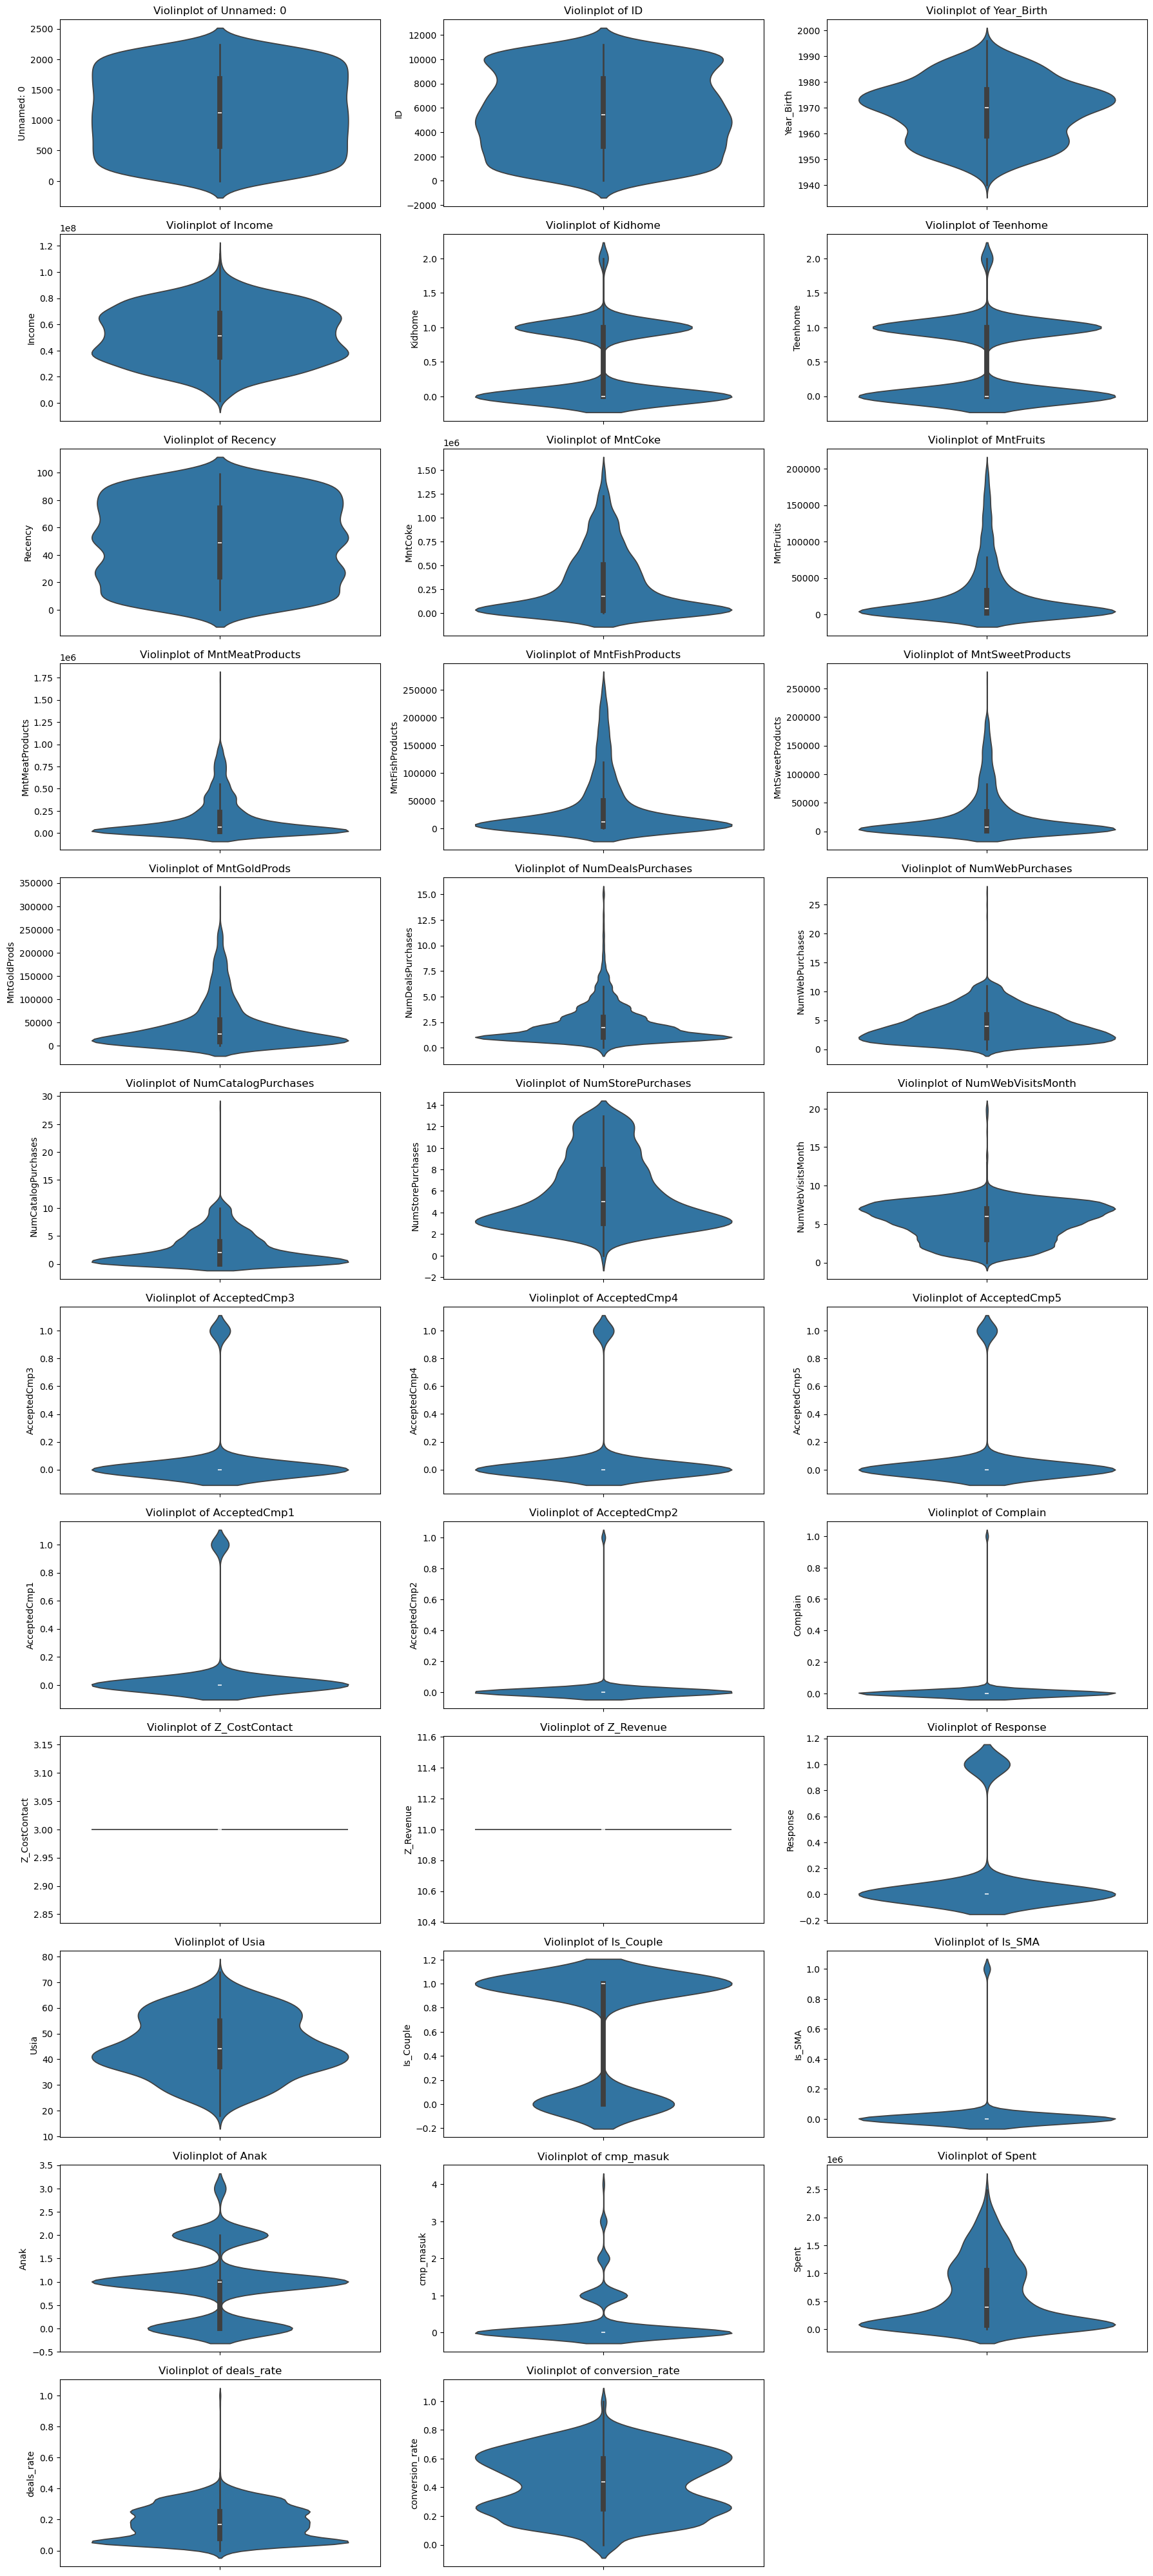

In [62]:
# Univariate Analysis

numerical_cols = new_df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3

plt.figure(figsize=(18,50))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(15, n_cols, i)
    sns.violinplot(y=new_df[col])
    plt.title(f'Violinplot of {col}')

plt.tight_layout()
plt.show()

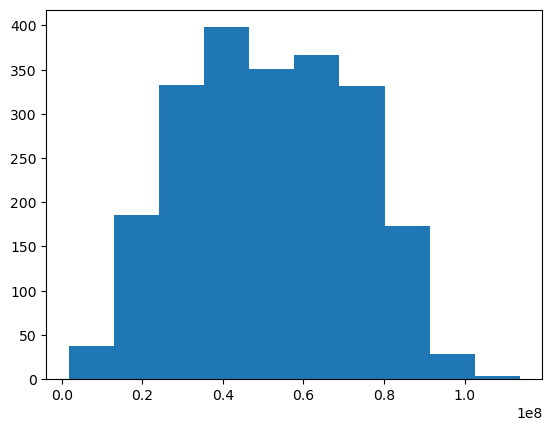

In [63]:
plt.Figure(figsize=(10,50))
plt.hist(new_df['Income'])
plt.show()

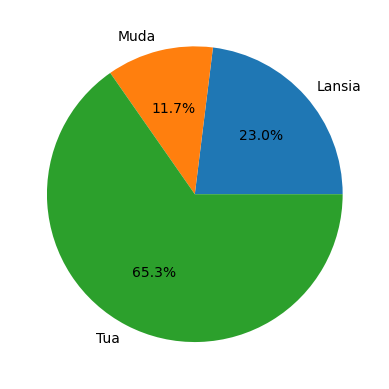

In [77]:
pivot = new_df.groupby('rentang').agg({'ID':'nunique'}).reset_index()

mylabels = np.array(pivot['rentang'])
x = np.array(pivot['ID'])
plt.pie(x, labels=mylabels,autopct='%1.1f%%')
plt.show()

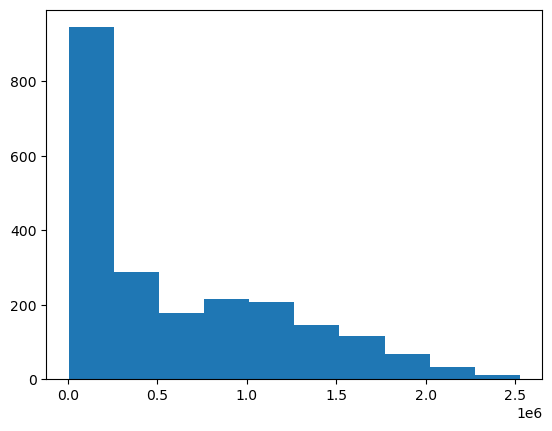

In [83]:
plt.Figure(figsize=(10,50))
plt.hist(new_df['Spent'])
plt.show()

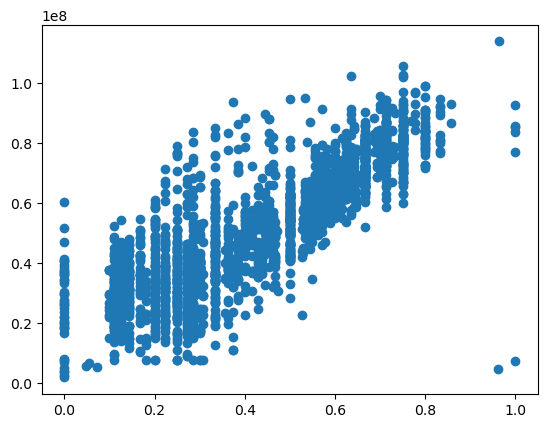

In [85]:
#Bivariate Analysis
plt.Figure(figsize=(10,50))
plt.scatter(new_df['conversion_rate'],new_df['Income'])
plt.show()

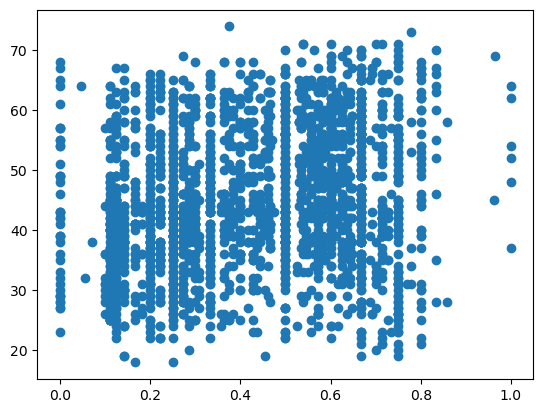

In [87]:
plt.Figure(figsize=(10,50))
plt.scatter(new_df['conversion_rate'],new_df['Usia'])
plt.show()

In [95]:
pivot = new_df.groupby(['rentang']).agg({'conversion_rate':'mean'}).reset_index()
pivot.sort_values('conversion_rate', ascending=False, inplace=True)

<BarContainer object of 3 artists>

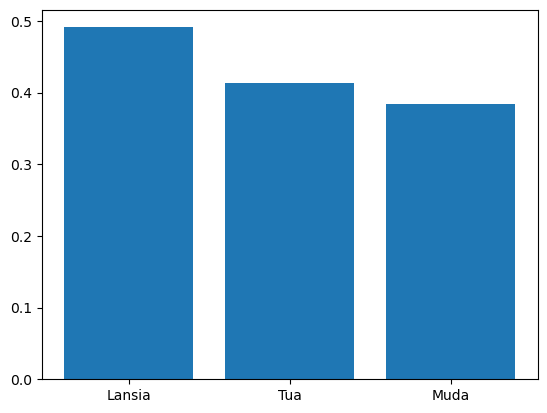

In [96]:
plt.Figure(figsize=(10,50))
plt.bar(pivot['rentang'],pivot['conversion_rate'])

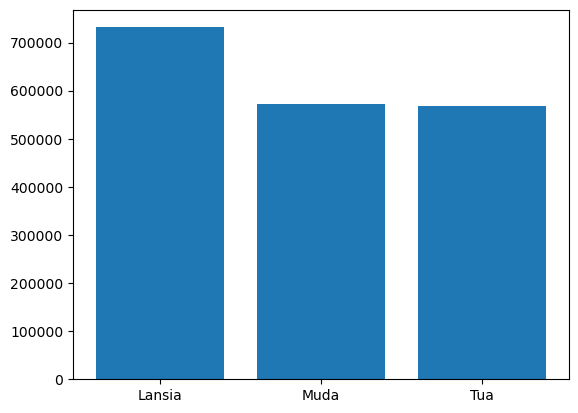

In [105]:
pivot = new_df.groupby(['rentang']).agg({'Spent':'mean'}).reset_index()
pivot.sort_values('Spent', ascending=False, inplace=True)
plt.Figure(figsize=(10,50))
plt.bar(pivot['rentang'],pivot['Spent'])
plt.show()

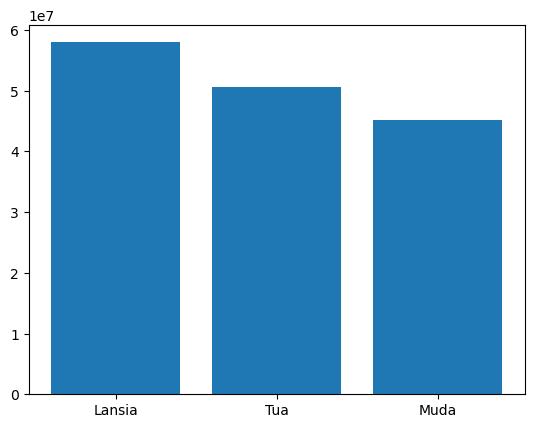

In [106]:
pivot = new_df.groupby(['rentang']).agg({'Income':'mean'}).reset_index()
pivot.sort_values('Income', ascending=False, inplace=True)
plt.Figure(figsize=(10,50))
plt.bar(pivot['rentang'],pivot['Income'])
plt.show()